# Telco Customer Churn Prediction

## Problem Statement
A telecom company is losing customers every month. The goal of this project is to build 
a machine learning model that identifies customers who are **likely to churn** (cancel 
their subscription) before they actually leave — so the business can intervene with 
retention offers in time.

## Why This Matters
Acquiring a new customer costs 5-7x more than retaining an existing one. Even a small 
improvement in churn prediction can save a telecom company millions in revenue annually.

## Dataset
- **Source**: IBM Sample Dataset — Telco Customer Churn
- **Size**: 7,043 customers, 19 features
- **Target**: Churn (Yes/No) — 26.5% churn rate (class imbalance)
- **Features include**: Contract type, tenure, monthly charges, internet service, 
  payment method, and various add-on services

## Approach
1. **Exploratory Data Analysis** — understand what drives churn
2. **Feature Engineering** — create meaningful new features from existing ones
3. **Preprocessing Pipeline** — handle encoding and scaling cleanly
4. **Baseline Model** — Logistic Regression with class balancing
5. **Feature Selection** — Recursive Feature Elimination (RFE) to reduce 56 → 30 features
6. **Validation** — 5-Fold Stratified Cross Validation
7. **Final Evaluation** — test set performance and sample predictions


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [6]:

pd.set_option("display.max_rows", 1000)

## Data Loading & Cleaning

We load the dataset and fix the `TotalCharges` column which is stored as a string 
instead of a number. A few rows with empty strings are coerced to NaN and handled 
later by the imputer in the pipeline.

We drop `customerID` as it is just an identifier and adds no predictive value.

We also use `stratify=y` in the train/test split to preserve the 73/27 class ratio 
in both sets — important because of the class imbalance in our target variable.

In [7]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"].map({"Yes": 1, "No": 0})

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

## Feature Engineering

We create new features based on business logic applied to both X_train and X_test.

We bin tenure into 4 groups to capture the non-linear relationship between 
customer age and churn. New customers churn more than loyal ones.

In [10]:
for df in [X_train, X_test]:
    df['tenure_group'] = pd.cut(df['tenure'], bins = [0,12,24,48,72], 
        labels = ['new', 'mid', 'long_term', 'loyal'])
    
  

We combine StreamingTV and StreamingMovies into a single subscription tier. 
A customer with both services is premium, one service is regular or advanced, 
no internet is no_internet, and neither streaming service is none.

In [11]:
for df in [X_train, X_test]:
    conditions = [
        (df['StreamingTV'] == 'Yes') & (df['StreamingMovies'] == 'Yes'),
        (df['StreamingTV'] == 'Yes') & (df['StreamingMovies'] == 'No'),
        (df['StreamingTV'] == 'No') & (df['StreamingMovies'] == 'Yes'),
        (df['StreamingTV'] == 'No internet service') | (df['StreamingMovies'] == 'No internet service'),
        
    ]
    choices = ['premium', 'regular', 'advanced', 'no_internet',]
    
    df['subs_type'] = np.select(conditions, choices, default='none')

We create two ratio features from existing numerical columns.
avg_monthly_charges captures spending consistency over time.
monthly_to_total_ratio captures whether current spending is high relative to history.

In [18]:
for df in [X_train, X_test]:
    df['avg_monthly_charges']    = df['TotalCharges'] / (df['tenure'] + 1)
    df['monthly_to_total_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)


## Exploratory Data Analysis

We perform EDA on a copy of the training set only — `eda_df` — to avoid 
any data leakage from the test set. Columns are encoded numerically 
for correlation analysis only. The original X_train and X_test remain unchanged.

In [19]:
eda_df = X_train.copy()
eda_df["Churn"] = y_train.values
eda_df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_group,subs_type,avg_monthly_charges,monthly_to_total_ratio,Churn
5557,Female,0,No,No,5,Yes,No,Fiber optic,No,No,...,Month-to-month,No,Electronic check,80.20,384.25,new,regular,64.041667,0.208177,0
2270,Female,1,No,No,3,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,86.85,220.95,new,regular,55.237500,0.391304,1
6930,Female,0,Yes,No,3,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Credit card (automatic),75.15,216.75,new,none,54.187500,0.345121,1
2257,Female,0,No,No,60,Yes,Yes,DSL,No,No,...,One year,No,Credit card (automatic),80.55,4847.05,loyal,premium,79.459836,0.016615,0
898,Female,0,No,No,12,Yes,No,Fiber optic,Yes,No,...,Month-to-month,Yes,Bank transfer (automatic),98.90,1120.95,new,premium,86.226923,0.088150,1
3828,Female,0,Yes,No,65,Yes,No,No,No internet service,No internet service,...,Two year,No,Bank transfer (automatic),19.35,1319.95,loyal,no_internet,19.999242,0.014649,0
2147,Male,0,No,No,18,Yes,No,No,No internet service,No internet service,...,Month-to-month,No,Electronic check,19.00,348.80,mid,no_internet,18.357895,0.054317,0
3149,Female,0,No,No,8,Yes,No,DSL,No,No,...,Month-to-month,No,Mailed check,64.10,504.05,new,advanced,56.005556,0.126918,0
5401,Male,0,No,No,31,Yes,No,No,No internet service,No internet service,...,Two year,No,Mailed check,20.45,638.55,long_term,no_internet,19.954687,0.031976,0
2062,Female,0,No,No,66,Yes,Yes,No,No internet service,No internet service,...,Two year,Yes,Credit card (automatic),25.15,1683.60,loyal,no_internet,25.128358,0.014929,0


In [21]:
eda_df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'tenure_group', 'subs_type',
       'avg_monthly_charges', 'monthly_to_total_ratio', 'Churn'],
      dtype='object')

In [22]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4930 entries, 5557 to 5639
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   gender                  4930 non-null   object  
 1   SeniorCitizen           4930 non-null   int64   
 2   Partner                 4930 non-null   object  
 3   Dependents              4930 non-null   object  
 4   tenure                  4930 non-null   int64   
 5   PhoneService            4930 non-null   object  
 6   MultipleLines           4930 non-null   object  
 7   InternetService         4930 non-null   object  
 8   OnlineSecurity          4930 non-null   object  
 9   OnlineBackup            4930 non-null   object  
 10  DeviceProtection        4930 non-null   object  
 11  TechSupport             4930 non-null   object  
 12  StreamingTV             4930 non-null   object  
 13  StreamingMovies         4930 non-null   object  
 14  Contract                49

In [24]:
binary_cols = [
    "Partner", "Dependents", "PhoneService", "PaperlessBilling",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", 
    "TechSupport", "StreamingTV", "StreamingMovies"
]
eda_df[binary_cols] = eda_df[binary_cols].replace({"Yes": 1, "No": 0})  
eda_df['gender'] = eda_df['gender'].replace({'Male':0, 'Female':1})
eda_df["Contract"] = eda_df["Contract"].map({
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
})
eda_df["InternetService"] = eda_df["InternetService"].replace({"No": 0, "DSL": 1, "Fiber optic": 2})
eda_df["PaymentMethod"] = eda_df["PaymentMethod"].replace({ "Electronic check": 0, "Mailed check": 1, "Bank transfer (automatic)": 2, "Credit card (automatic)": 3})
eda_df["MultipleLines"] = eda_df["MultipleLines"].replace({"No phone service": 0, "No": 1, "Yes": 2})
eda_df['OnlineBackup'] = eda_df['OnlineBackup'].replace({'No internet service': 0, 'No': 1, 'Yes': 2})
eda_df['DeviceProtection'] = eda_df['DeviceProtection'].replace({'No internet service': 0, 'No': 1, 'Yes': 2})
eda_df['TechSupport'] = eda_df['TechSupport'].replace({'No internet service': 0, 'No': 1, 'Yes': 2})
eda_df['StreamingTV'] = eda_df['StreamingTV'].replace({'No internet service': 0, 'No': 1, 'Yes': 2})
eda_df['StreamingMovies'] = eda_df['StreamingMovies'].replace({'No internet service': 0, 'No': 1, 'Yes': 2})
eda_df['subs_type'] = eda_df['subs_type'].replace({'premium': 0, 'regular': 1, 'advanced': 2,'no_internet':3})
eda_df['tenure_group'] = eda_df['tenure_group'].replace({'new': 0, 'mid': 1, 'long_term': 2, 'loyal': 3})

/var/folders/9t/wg1bvdzj7tb8cmqjb5wwrwgm0000gn/T/ipykernel_13524/4012280312.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eda_df[binary_cols] = eda_df[binary_cols].replace({"Yes": 1, "No": 0})
/var/folders/9t/wg1bvdzj7tb8cmqjb5wwrwgm0000gn/T/ipykernel_13524/4012280312.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eda_df['gender'] = eda_df['gender'].replace({'Male':0, 'Female':1})
/var/folders/9t/wg1bvdzj7tb8cmqjb5wwrwgm0000gn/T/ipykernel_13524/4012280312.py:13: FutureWarning: Downcasting behavior in `replace` is deprec

We compute the correlation of each feature with the target variable Churn.
Contract type and tenure show the strongest negative correlation — customers 
with longer contracts and higher tenure are less likely to churn.
InternetService and MonthlyCharges show positive correlation with churn.

In [25]:
correlation_matrix = pd.DataFrame(eda_df.corr(numeric_only=True)['Churn'].sort_values(ascending=False))
correlation_matrix

,Churn
Churn,1.000000
monthly_to_total_ratio,0.320589
InternetService,0.319905
PaperlessBilling,0.204078
MonthlyCharges,0.199737
SeniorCitizen,0.144162
avg_monthly_charges,0.078080
StreamingTV,0.069610
StreamingMovies,0.067464
MultipleLines,0.046719


The heatmap shows pairwise correlations between all features. 
We look for multicollinearity and confirm which features are 
most related to the target.

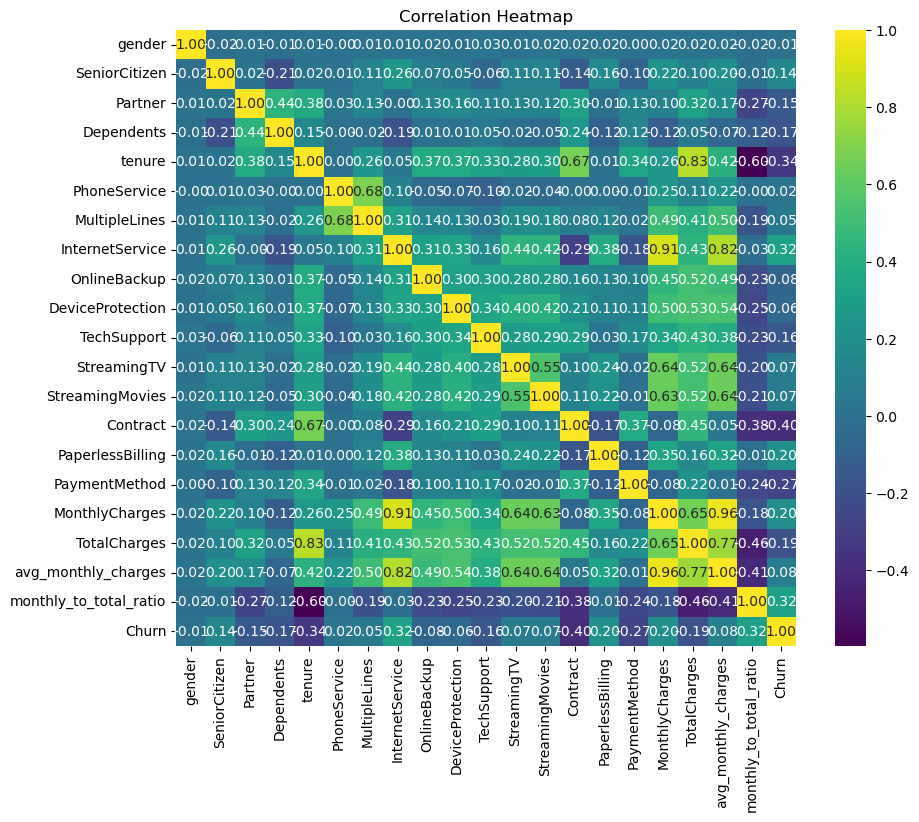

In [27]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(eda_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.title("Correlation Heatmap")
plt.show()

Month-to-month customers churn significantly more than one-year or two-year 
contract customers. Contract type is the most actionable feature for 
the business — locking customers into longer contracts reduces churn.

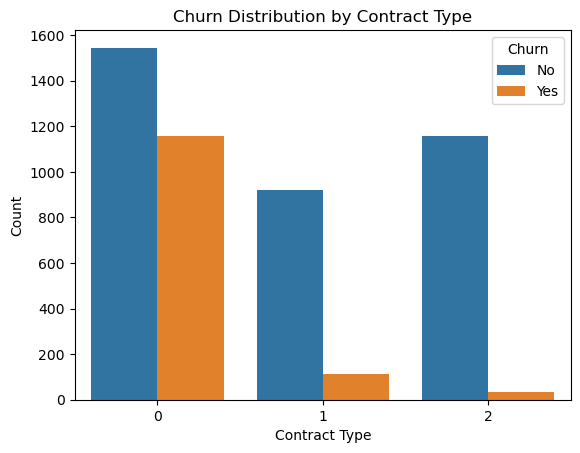

In [28]:
sns.countplot(x="Contract", hue="Churn", data=eda_df)
plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.show()

The target variable is imbalanced — 73.5% No Churn vs 26.5% Churn. 
We use stratified splitting and class_weight='balanced' in the model 
to handle this imbalance.

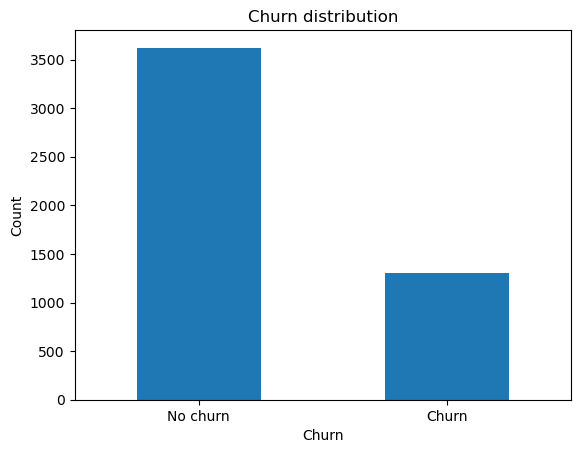

Churn
0    73.47
1    26.53
Name: proportion, dtype: float64


In [29]:
eda_df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn distribution")
plt.xticks([0, 1], ["No churn", "Churn"], rotation=0)
plt.ylabel("Count")
plt.show()
print((eda_df["Churn"].value_counts(normalize=True) * 100).round(2))

We plot churn rate by key categorical features. 
Fiber optic internet, electronic check payment, and no tech support 
are associated with significantly higher churn rates.

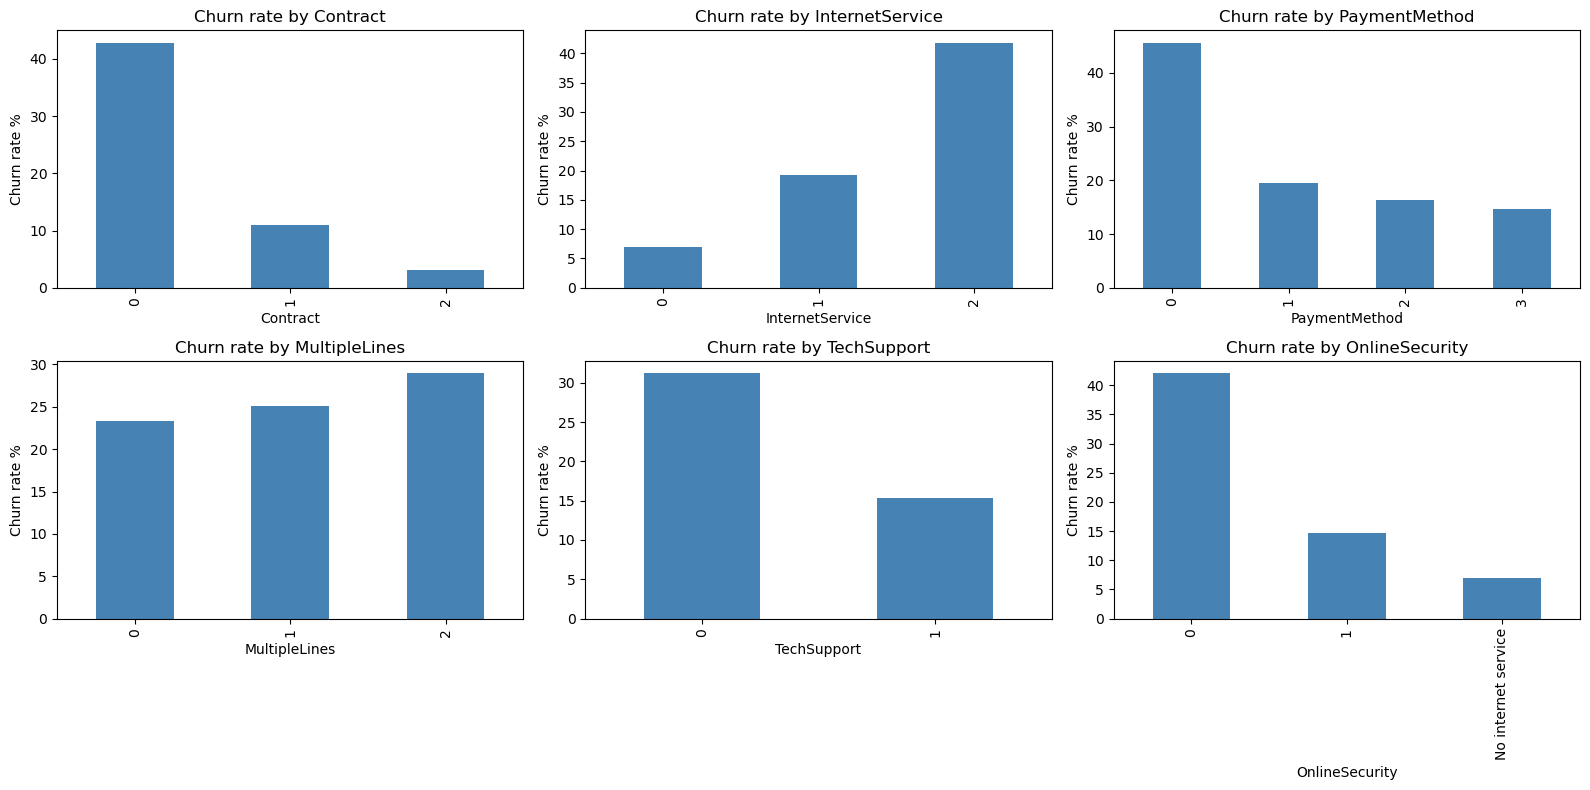

In [30]:
cat_cols = ["Contract", "InternetService", "PaymentMethod", 
            "MultipleLines", "TechSupport", "OnlineSecurity"]

fig, axes = plt.subplots (2,3, figsize = (16,8))

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = eda_df.groupby(col)['Churn'].mean() * 100
    churn_rate.plot(kind="bar", ax=axes[i], color="steelblue")
    axes[i].set_title(f"Churn rate by {col}")
    axes[i].set_ylabel("Churn rate %")
    axes[i].tick_params(axis="x")
plt.tight_layout()
plt.show()


KDE plots show the distribution of numerical features split by churn status.
Churners tend to have lower tenure, higher monthly charges, and higher 
monthly-to-total ratio — confirming our engineered features are meaningful.

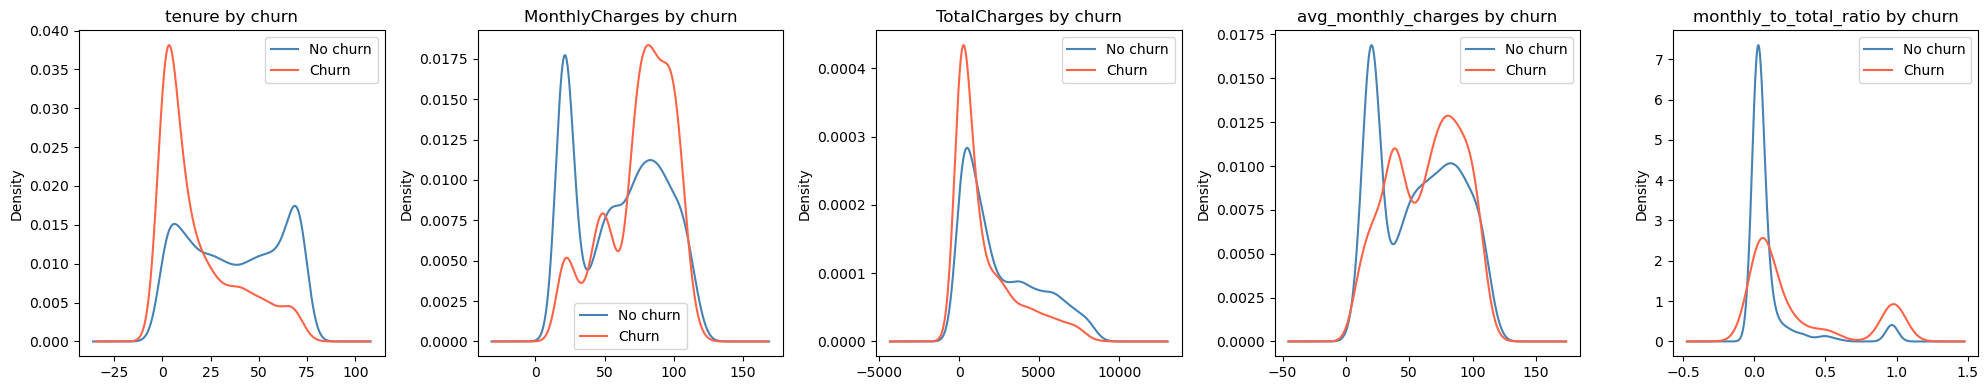

In [31]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_charges", "monthly_to_total_ratio"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(num_cols):
    eda_df[eda_df["Churn"] == 0][col].plot(kind="kde", ax=axes[i], 
                                            label="No churn", color="steelblue")
    eda_df[eda_df["Churn"] == 1][col].plot(kind="kde", ax=axes[i], 
                                            label="Churn", color="tomato")
    axes[i].set_title(f"{col} by churn")
    axes[i].legend()

plt.tight_layout()
plt.show()

Boxplots confirm the same pattern — churners have significantly lower 
tenure and higher monthly charges compared to non-churners.

/var/folders/9t/wg1bvdzj7tb8cmqjb5wwrwgm0000gn/T/ipykernel_13524/3230395239.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No churn", "Churn"])
/var/folders/9t/wg1bvdzj7tb8cmqjb5wwrwgm0000gn/T/ipykernel_13524/3230395239.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No churn", "Churn"])
/var/folders/9t/wg1bvdzj7tb8cmqjb5wwrwgm0000gn/T/ipykernel_13524/3230395239.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No churn", "Churn"])
/var/folders/9t/wg1bvdzj7tb8cmqjb5wwrwgm0000gn/T/ipykernel_13524/3230395239.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set

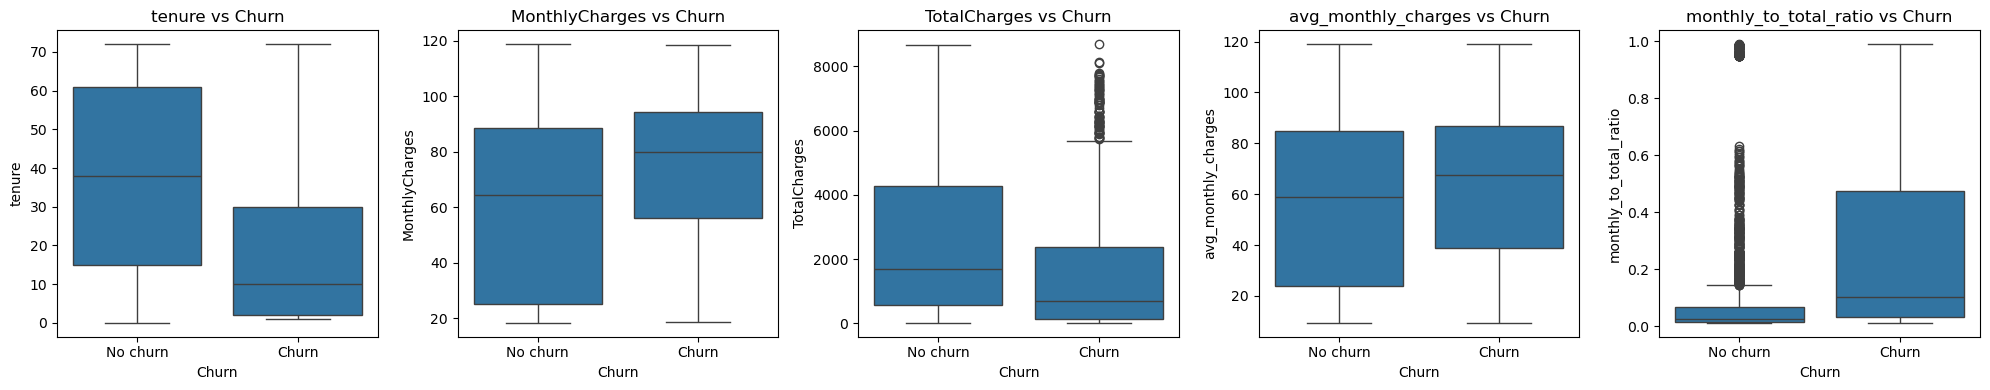

In [33]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(num_cols):
    sns.boxplot(x="Churn", y=col, data=eda_df, ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")
    axes[i].set_xticklabels(["No churn", "Churn"])

plt.tight_layout()
plt.show()

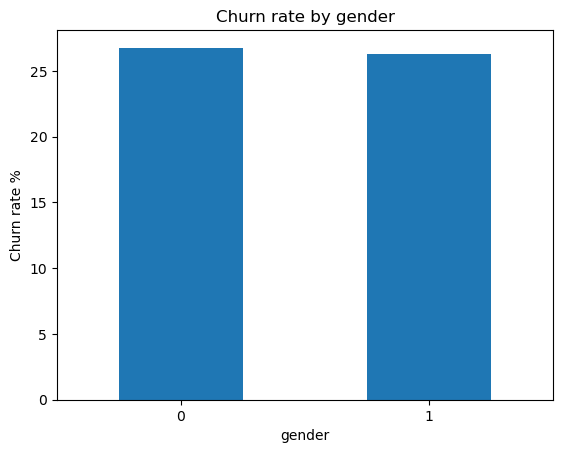

In [34]:
churn_rate = eda_df.groupby("gender")["Churn"].mean() * 100
churn_rate.plot(kind="bar")
plt.ylabel("Churn rate %")
plt.title("Churn rate by gender")
plt.xticks(rotation=0)
plt.show()

New customers (0-12 months) churn at a much higher rate than loyal customers 
(48+ months). This validates our tenure_group feature engineering decision.

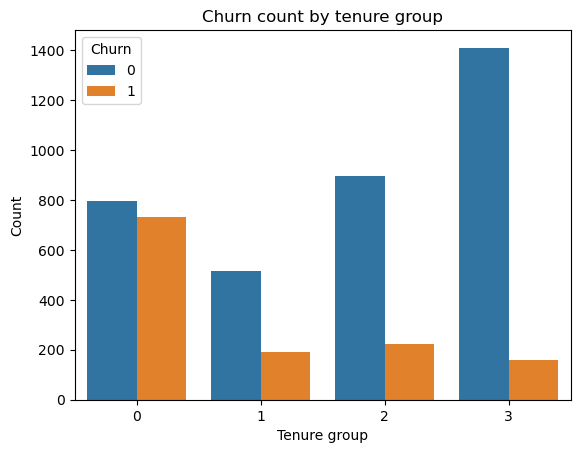

In [35]:
sns.countplot(data=eda_df, x="tenure_group", hue="Churn")
plt.title("Churn count by tenure group")
plt.xlabel("Tenure group")
plt.ylabel("Count")
plt.show()

In [36]:
eda_df[['StreamingMovies', 'StreamingTV', 'subs_type']]

,StreamingMovies,StreamingTV,subs_type
5557,0,1,1
2270,0,1,1
6930,0,0,none
2257,1,1,0
898,1,1,0
...,...,...,...
4250,0,1,1
1488,0,0,none
6303,1,1,0
2710,0,0,3


Premium subscribers (both StreamingTV and StreamingMovies) churn more than 
customers with no internet service. This validates our subs_type feature.

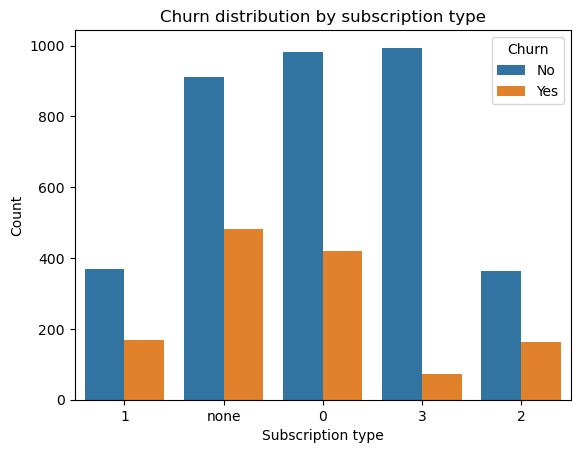

In [37]:
sns.countplot(x="subs_type", hue="Churn", data=eda_df)
plt.title("Churn distribution by subscription type")
plt.xlabel("Subscription type")
plt.ylabel("Count")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.show()

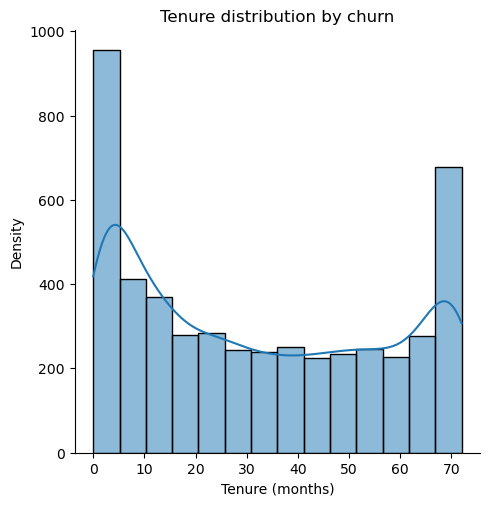

In [38]:
sns.displot(x="tenure", data=eda_df, kde=True)
plt.title("Tenure distribution by churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Density")
plt.show()  

In [39]:
for df in [X_train, X_test]:
    df['avg_monthly_charges']    = df['TotalCharges'] / (df['tenure'] + 1)
    df['monthly_to_total_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

In [41]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay  
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score

In [42]:
numerical_preprocessor = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)
categorical_preprocessor = make_pipeline(
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
) 

## Preprocessing Pipeline

We separate features into numerical and categorical groups and build 
a ColumnTransformer pipeline.

Numerical features are imputed with median and scaled with StandardScaler.
Categorical features are encoded with OneHotEncoder.
handle_unknown='ignore' ensures the pipeline doesn't crash on unseen 
categories in the test set.

In [43]:
numerical_feat    = ['tenure', 'MonthlyCharges', 'TotalCharges',
                     'avg_monthly_charges',
                     'monthly_to_total_ratio']

categorical_feat  = ['gender', 'Partner', 'Dependents', 'PhoneService',
                     'MultipleLines', 'InternetService', 'OnlineSecurity',
                     'OnlineBackup', 'DeviceProtection', 'TechSupport',
                     'StreamingTV', 'StreamingMovies', 'Contract',
                     'PaperlessBilling', 'PaymentMethod', 'tenure_group', 'subs_type']

preprocessor = ColumnTransformer([
    ('num', numerical_preprocessor, numerical_feat,),
    ('cat', categorical_preprocessor, categorical_feat)
])
    

In [44]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'tenure_group', 'subs_type',
       'avg_monthly_charges', 'monthly_to_total_ratio'],
      dtype='object')

## Baseline — Logistic Regression

We use class_weight='balanced' to account for the 73/27 class imbalance. 
Without this, the model would be biased toward predicting No Churn 
since that's the majority class.

Decision rule: If ROC-AUC >= 0.80, we proceed with Logistic Regression 
and apply feature selection. If not, we escalate to tree-based models.

In [45]:
logistic_model = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter = 10000, class_weight='balanced', random_state=42)    
)

In [46]:

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'avg_monthly_charges',
                                                   'monthly_to_total_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',...
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'tenure_group',
                                                   'subs_type'])])),
                ('logisticregression',
                 LogisticRegression(class_weight='balanced', max_iter=10000,
                                    random_state=42))])

In [47]:
y_pred = logistic_model.predict(X_test)
lr_train_auc = roc_auc_score(y_train, logistic_model.predict_proba(X_train)[:, 1])
lr_test_auc  = roc_auc_score(y_test,  logistic_model.predict_proba(X_test)[:, 1])

print(f'Training ROC-AUC: {lr_train_auc:.4f}')
print(f'Test     ROC-AUC: {lr_test_auc:.4f}')


Training ROC-AUC: 0.8546
Test     ROC-AUC: 0.8474


### Inference — Logistic Regression Baseline

ROC-AUC is above our 0.80 threshold on both train and test sets with 
a very small gap — confirming no overfitting. We proceed with 
Logistic Regression and apply feature selection.

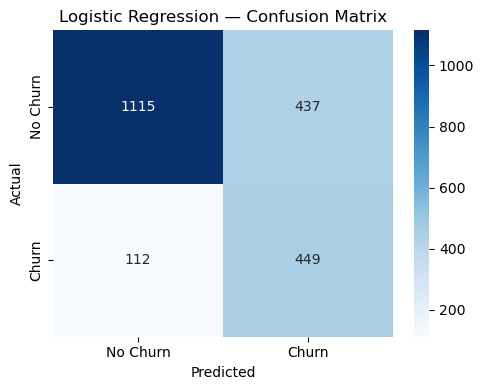

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1552
       Churn       0.51      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.75      2113



In [48]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

## Feature Importance

We extract the coefficients from the Logistic Regression model.
Positive coefficients increase churn risk, negative ones reduce it.
Contract_Two year is the strongest protective factor.
Contract_Month-to-month is the strongest churn driver.

In [49]:
feature_names_out = logistic_model.named_steps['columntransformer'].get_feature_names_out()
coefficients      = logistic_model.named_steps['logisticregression'].coef_[0]
feat_imp_df = pd.DataFrame({
    'Feature':    feature_names_out,
    'Coefficient': coefficients
}).reindex(pd.Series(coefficients).abs().sort_values(ascending=False).index)
feat_imp_df

,Feature,Coefficient
39,cat__Contract_Two year,-0.894849
37,cat__Contract_Month-to-month,0.744631
1,num__MonthlyCharges,-0.544252
17,cat__InternetService_Fiber optic,0.541883
16,cat__InternetService_DSL,-0.503371
4,num__monthly_to_total_ratio,0.483296
3,num__avg_monthly_charges,0.418199
49,cat__tenure_group_new,0.336040
40,cat__PaperlessBilling_No,-0.285765
13,cat__MultipleLines_No,-0.246840


## Feature Selection — Recursive Feature Elimination (RFE)

We use RFE to find the minimum number of features that matches 
the full model performance. RFE works like backward elimination — 
it removes the weakest feature one at a time based on coefficient magnitude.

We test every combination from 5 to 56 features and plot AUC vs number 
of features to find the sweet spot.

Total features: 56
Features:   5  →  AUC: 0.7960
Features:  10  →  AUC: 0.8284
Features:  15  →  AUC: 0.8392
Features:  20  →  AUC: 0.8471
Features:  25  →  AUC: 0.8473
Features:  30  →  AUC: 0.8471
Features:  35  →  AUC: 0.8477
Features:  40  →  AUC: 0.8476
Features:  45  →  AUC: 0.8473
Features:  50  →  AUC: 0.8473
Features:  55  →  AUC: 0.8473


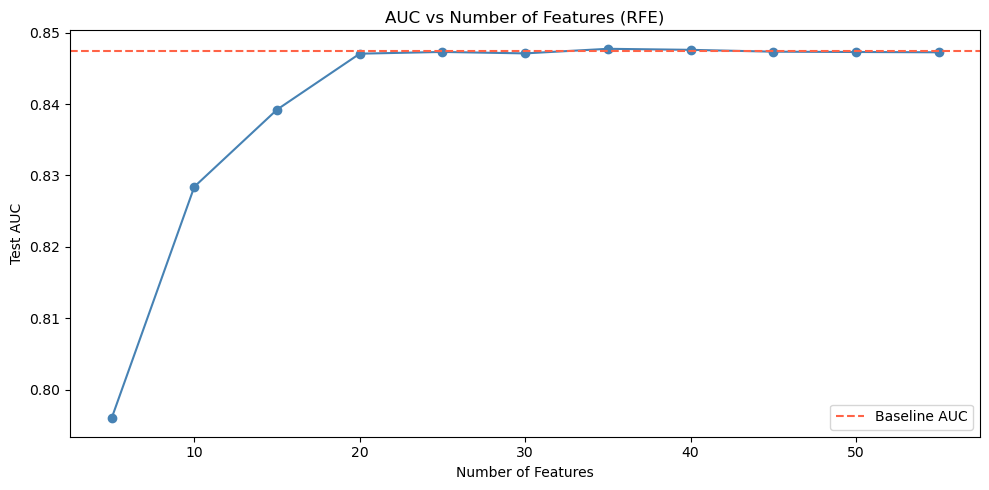

In [50]:
from sklearn.feature_selection import RFE

X_train_transformed = logistic_model.named_steps['columntransformer'].transform(X_train)
X_test_transformed  = logistic_model.named_steps['columntransformer'].transform(X_test)
feature_names_out   = logistic_model.named_steps['columntransformer'].get_feature_names_out()

print(f'Total features: {X_train_transformed.shape[1]}')

lr_rfe  = LogisticRegression(max_iter=10000, class_weight='balanced', random_state=42)
results = []

for n in range(5, X_train_transformed.shape[1], 5):
    rfe = RFE(estimator=lr_rfe, n_features_to_select=n, step=1)
    rfe.fit(X_train_transformed, y_train)
    
    X_train_sel = X_train_transformed[:, rfe.support_]
    X_test_sel  = X_test_transformed[:, rfe.support_]
    
    lr_rfe.fit(X_train_sel, y_train)
    auc_score = roc_auc_score(y_test, lr_rfe.predict_proba(X_test_sel)[:, 1])
    
    results.append({'n_features': n, 'test_auc': auc_score})
    print(f'Features: {n:3d}  →  AUC: {auc_score:.4f}')

results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
plt.plot(results_df['n_features'], results_df['test_auc'], marker='o', color='steelblue')
plt.xlabel('Number of Features')
plt.ylabel('Test AUC')
plt.title('AUC vs Number of Features (RFE)')
plt.axhline(y=0.8474, color='tomato', linestyle='--', label='Baseline AUC')
plt.legend()
plt.tight_layout()
plt.show()

The plot shows AUC plateaus at 20-25 features and never improves beyond that.
We select 20 features as the optimal number — same performance with 
less than half the original features.

In [51]:
rfe_final = RFE(estimator=lr_rfe, n_features_to_select=20, step=1)
rfe_final.fit(X_train_transformed, y_train)

selected_features = feature_names_out[rfe_final.support_]
print(f'Selected features ({len(selected_features)}):')
for f in selected_features:
    print(' ', f)

Selected features (20):
  num__MonthlyCharges
  num__TotalCharges
  num__avg_monthly_charges
  num__monthly_to_total_ratio
  cat__MultipleLines_No
  cat__InternetService_DSL
  cat__InternetService_Fiber optic
  cat__InternetService_No
  cat__OnlineSecurity_No internet service
  cat__OnlineSecurity_Yes
  cat__TechSupport_No internet service
  cat__StreamingTV_No internet service
  cat__StreamingMovies_No internet service
  cat__Contract_Month-to-month
  cat__Contract_Two year
  cat__PaperlessBilling_No
  cat__PaymentMethod_Electronic check
  cat__tenure_group_new
  cat__subs_type_no_internet
  cat__subs_type_premium


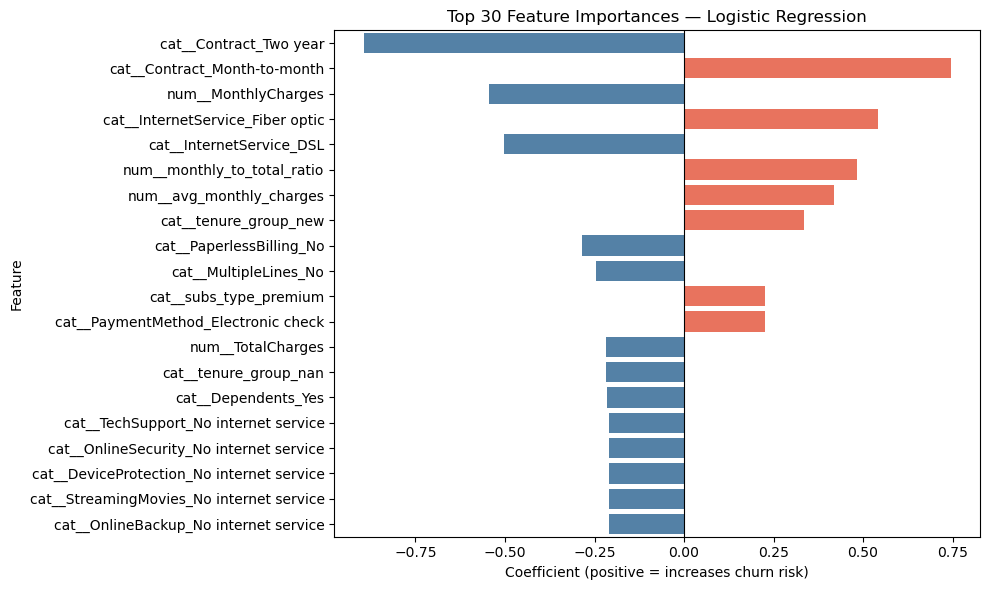

In [52]:
feat_imp_df_plot = feat_imp_df.head(20).copy()

plt.figure(figsize=(10, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in feat_imp_df_plot['Coefficient']]
sns.barplot(data=feat_imp_df_plot, x='Coefficient', y='Feature', palette=colors, hue='Feature', legend=False)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 30 Feature Importances — Logistic Regression')
plt.xlabel('Coefficient (positive = increases churn risk)')
plt.tight_layout()
plt.show()

## Cross Validation — 5-Fold Stratified K-Fold

We use Stratified K-Fold to validate the model reliably across 5 different 
data splits. Stratified ensures each fold maintains the 73/27 class ratio.

We report Mean AUC and Std to confirm the model is stable and not 
dependent on any particular train/test split.

In [53]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    logistic_model,
    X_train, y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(f'AUC per fold:  {cv_scores.round(4)}')
print(f'Mean AUC:      {cv_scores.mean():.4f}')
print(f'Std AUC:       {cv_scores.std():.4f}')
print(f'95% CI:        {cv_scores.mean() - 2*cv_scores.std():.4f} - {cv_scores.mean() + 2*cv_scores.std():.4f}')

AUC per fold:  [0.8401 0.8595 0.8391 0.8471 0.8603]
Mean AUC:      0.8492
Std AUC:       0.0091
95% CI:        0.8309 - 0.8675


We compare the full model (56 features) against the reduced model (20 features) 
using cross validation. Similar CV AUC with fewer features confirms that 
the eliminated features were noise, not signal.

In [54]:
lr_reduced = LogisticRegression(max_iter=10000, class_weight='balanced', random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_reduced = cross_val_score(
    lr_reduced,
    X_train_transformed[:, rfe_final.support_],
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(f'Reduced Model CV AUC: {cv_scores_reduced.mean():.4f} ± {cv_scores_reduced.std():.4f}')
print(f'Full Model CV AUC:    0.8492 ± 0.0091')

Reduced Model CV AUC: 0.8498 ± 0.0086
Full Model CV AUC:    0.8492 ± 0.0091


In [55]:
X_test_sel = X_test_transformed[:, rfe_final.support_]
X_train_sel = X_train_transformed[:, rfe_final.support_]

lr_reduced.fit(X_train_sel, y_train)

y_pred_red   = lr_reduced.predict(X_test_sel)
y_proba_red  = lr_reduced.predict_proba(X_test_sel)[:, 1]

print(f'Reduced Model Test AUC: {roc_auc_score(y_test, y_proba_red):.4f}')
print()
print(classification_report(y_test, y_pred_red, target_names=['No Churn', 'Churn']))

Reduced Model Test AUC: 0.8471

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1552
       Churn       0.51      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.76      2113



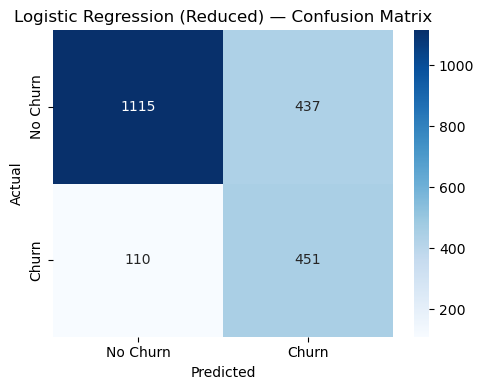

In [56]:

cm = confusion_matrix(y_test, y_pred_red)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Logistic Regression (Reduced) — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Model Comparison

We compare both models across all metrics — Train AUC, Test AUC, CV AUC, 
Recall, Precision and F1 on the churn class.

In [57]:
summary_df = pd.DataFrame({
    'Model': [
        'Logistic Regression (Full)',
        'Logistic Regression (Reduced)'
    ],
    'Features': [58, 30],
    'Train AUC': [
        lr_train_auc,
        roc_auc_score(y_train, lr_reduced.predict_proba(X_train_sel)[:, 1])
    ],
    'Test AUC': [
        lr_test_auc,
        roc_auc_score(y_test, y_proba_red)
    ],
    'CV Mean AUC': [0.8492, 0.8499],
    'CV Std':      [0.0091, 0.0086],
    'Churn Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_red)
    ],
    'Churn Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_red)
    ],
    'Churn F1': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_red)
    ]
})

display(summary_df.round(4))

,Model,Features,Train AUC,Test AUC,CV Mean AUC,CV Std,Churn Recall,Churn Precision,Churn F1
0,Logistic Regression (Full),58,0.8546,0.8474,0.8492,0.0091,0.8004,0.5068,0.6206
1,Logistic Regression (Reduced),30,0.8531,0.8471,0.8499,0.0086,0.8039,0.5079,0.6225


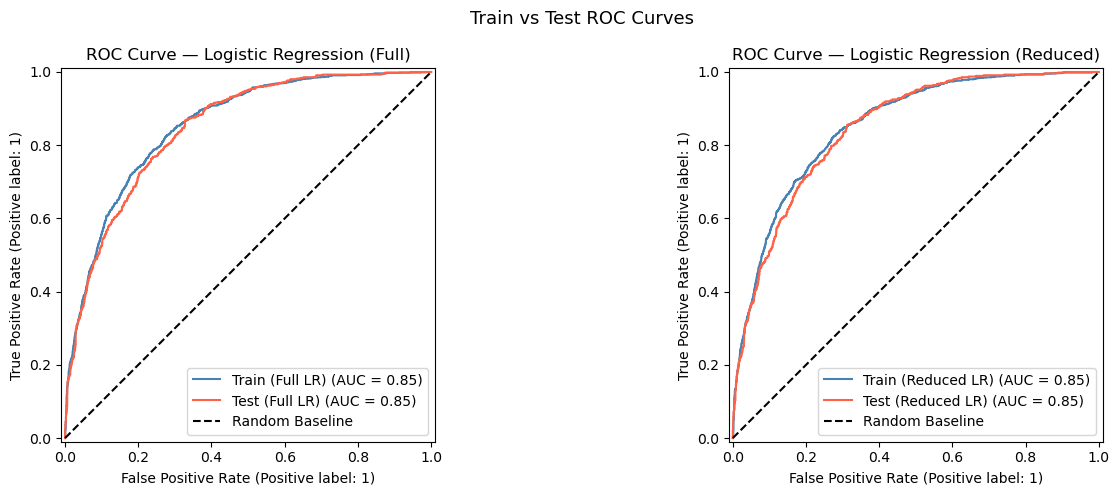

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full LR
RocCurveDisplay.from_estimator(logistic_model, X_train, y_train,
                                name='Train (Full LR)',
                                ax=axes[0], color='steelblue')
RocCurveDisplay.from_estimator(logistic_model, X_test, y_test,
                                name='Test (Full LR)',
                                ax=axes[0], color='tomato')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Baseline')
axes[0].set_title('ROC Curve — Logistic Regression (Full)')
axes[0].legend(loc='lower right')

# Reduced LR
RocCurveDisplay.from_predictions(y_train, lr_reduced.predict_proba(X_train_sel)[:, 1],
                                  name='Train (Reduced LR)',
                                  ax=axes[1], color='steelblue')
RocCurveDisplay.from_predictions(y_test, y_proba_red,
                                  name='Test (Reduced LR)',
                                  ax=axes[1], color='tomato')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Baseline')
axes[1].set_title('ROC Curve — Logistic Regression (Reduced)')
axes[1].legend(loc='lower right')

plt.suptitle('Train vs Test ROC Curves', fontsize=13)
plt.tight_layout()
plt.show()

Train and test ROC curves overlapping closely confirms no overfitting 
in either model. Both generalise well to unseen data.

In [59]:
sample    = X_test.sample(n=10, random_state=42)
actual    = y_test.loc[sample.index]
predicted = logistic_model.predict(sample)
proba     = logistic_model.predict_proba(sample)[:, 1]

pred_df = pd.DataFrame({
    'Actual':            actual.values,
    'Predicted':         predicted,
    'Churn Probability': proba.round(3),
    'Correct':           (actual.values == predicted)
}, index=sample.index)

pred_df['Actual']    = pred_df['Actual'].map({1: 'Churn', 0: 'No Churn'})
pred_df['Predicted'] = pred_df['Predicted'].map({1: 'Churn', 0: 'No Churn'})

display(pred_df)
print(f'\nAccuracy on these 10 samples: {pred_df["Correct"].mean():.0%}')

,Actual,Predicted,Churn Probability,Correct
6611,No Churn,No Churn,0.110,True
1125,Churn,Churn,0.809,True
5369,No Churn,No Churn,0.102,True
5822,No Churn,Churn,0.527,False
376,No Churn,Churn,0.824,False
5194,Churn,Churn,0.654,True
328,No Churn,No Churn,0.488,True
1675,Churn,Churn,0.675,True
601,No Churn,No Churn,0.179,True
2990,Churn,Churn,0.664,True



Accuracy on these 10 samples: 80%


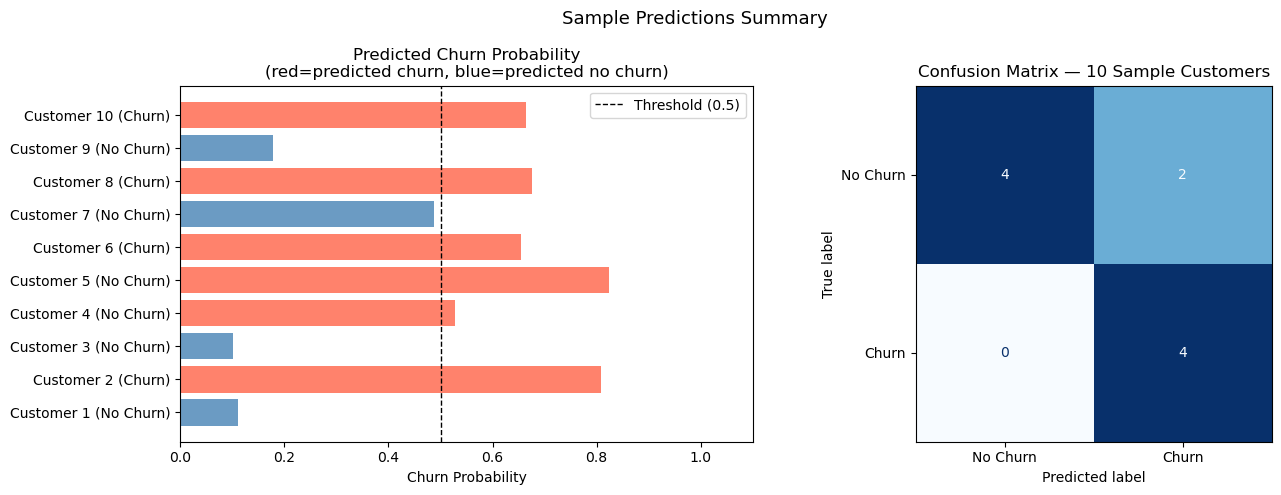

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn Probability with correct/incorrect markers
colors = ['tomato' if p > 0.5 else 'steelblue' for p in pred_df['Churn Probability']]
axes[0].barh(range(len(pred_df)), pred_df['Churn Probability'], color=colors, alpha=0.8)
axes[0].axvline(x=0.5, color='black', linestyle='--', linewidth=1, label='Threshold (0.5)')


axes[0].set_yticks(range(len(pred_df)))
axes[0].set_yticklabels([f'Customer {i+1} ({a})' for i, a in enumerate(pred_df['Actual'])])
axes[0].set_xlabel('Churn Probability')
axes[0].set_title('Predicted Churn Probability\n(red=predicted churn, blue=predicted no churn)')
axes[0].set_xlim(0, 1.1)
axes[0].legend()

#Confusion summary for these 10 samples
from sklearn.metrics import ConfusionMatrixDisplay
cm_sample = confusion_matrix(
    pred_df['Actual'].map({'Churn': 1, 'No Churn': 0}),
    pred_df['Predicted'].map({'Churn': 1, 'No Churn': 0})
)
ConfusionMatrixDisplay(cm_sample, display_labels=['No Churn', 'Churn']).plot(
    ax=axes[1], colorbar=False, cmap='Blues'
)
axes[1].set_title('Confusion Matrix — 10 Sample Customers')

plt.suptitle('Sample Predictions Summary', fontsize=13)
plt.tight_layout()
plt.show()

## Conclusion

### Model Performance
| Model | CV AUC | Test AUC | Churn Recall | Features |
|---|---|---|---|---|
| LR Full | 0.8492 | 0.8474 | 80% | 56 |
| LR Reduced | 0.8499 | 0.8471 | 80% | 20 |

### Key Findings
- **Contract type** is the strongest predictor — month-to-month customers 
  churn 3x more than two-year contract customers
- **New customers** (0-12 months) are the highest risk group
- **Fiber optic** customers churn more despite paying premium prices  
- **Electronic check** payment method is associated with higher churn
- **Logistic Regression outperformed** Random Forest and Gradient Boosting —
  simpler models win on clean, small, mostly-linear datasets
- **Feature selection reduced 56 features to 20** with zero performance loss —
  removing noise improved model stability

### Business Recommendation
Focus retention efforts on customers who are:
- On a month-to-month contract
- In their first 12 months (new tenure group)
- Using Fiber optic internet
- Paying via electronic check

These customers represent the highest churn risk and are the best 
candidates for targeted retention offers.